In [53]:
import torch

from train import train
from cem_model import CEMModelWrapper
from data import get_dataloader

import argparse
import utils
from mapping import map_arg

import os
import json
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter


In [25]:
device='mps'
backbone = map_arg['resnet18'].to(device)
m = CEMModelWrapper(backbone, 10, 32, device=device).to(device)
state = torch.load("runs/20260307_000637/state.pth", weights_only=False, map_location='cpu')
m.load_state_dict(state['model_state'])
dset = get_dataloader('cifar10', 1)


100%|██████████| 170M/170M [00:27<00:00, 6.24MB/s] 


In [26]:
image, target = next(iter(dset.test_loader))

In [30]:
m.eval()
with torch.no_grad():
    logits, mask = m(image.to(device), return_maps=True)
mask = mask.squeeze(0)

In [31]:
print('True Class', target.item(), "Pred Class", logits.argmax(-1).item())

True Class 3 Pred Class 3


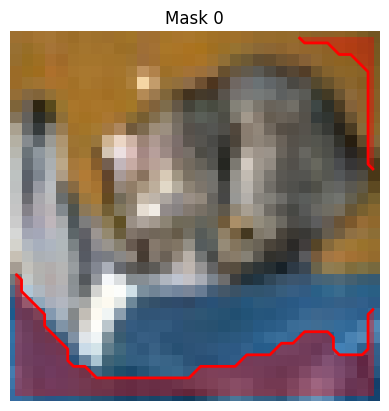

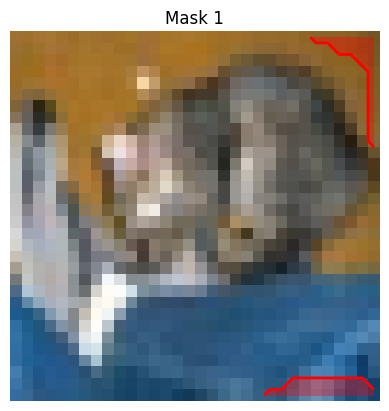

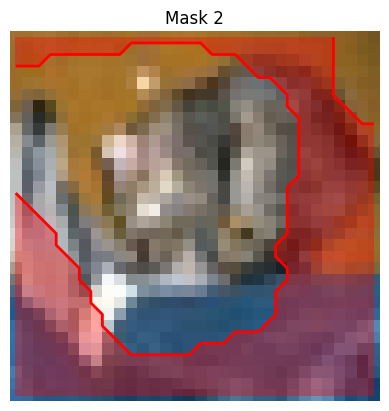

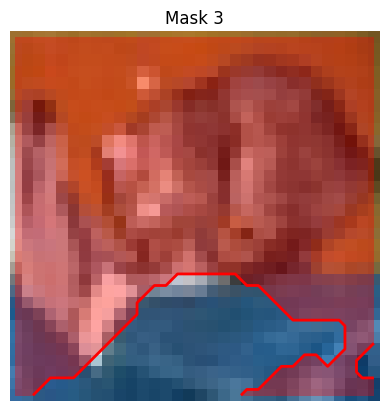

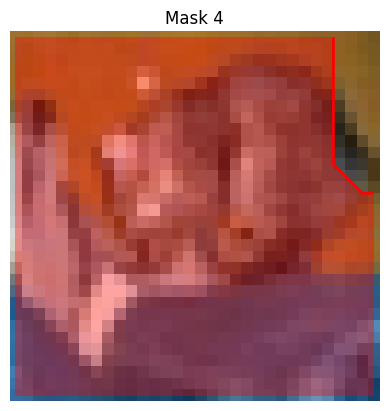

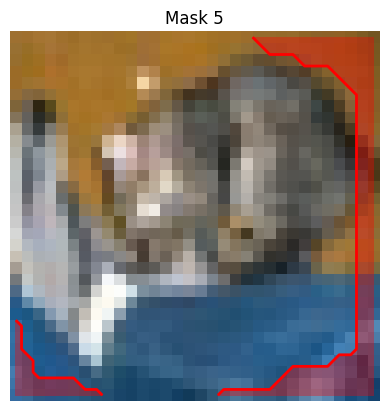

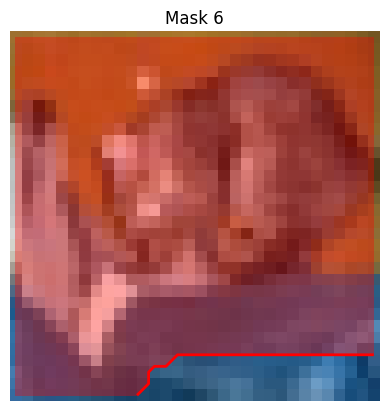

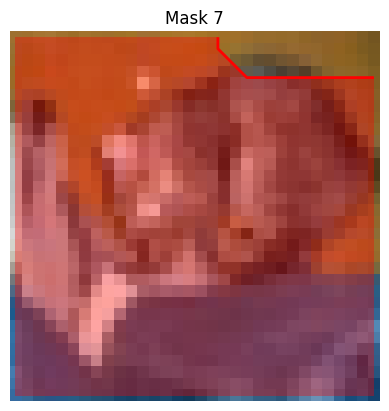

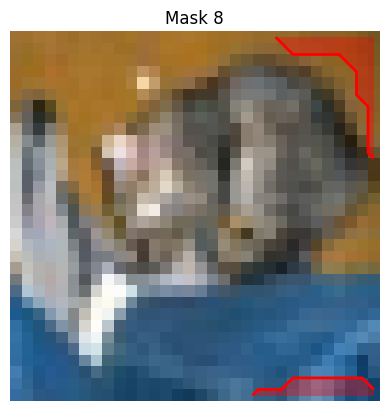

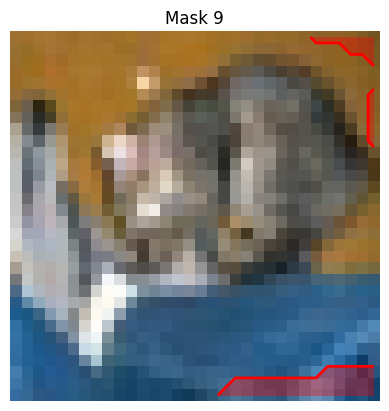

In [55]:
def plot_masks_separately(mask, image, dset, threshold=0.5):
    mask = mask.detach().cpu().numpy()

    if hasattr(image, "detach"):
        image = image.detach().cpu().numpy()

    # CHW -> HWC
    if image.ndim == 3 and image.shape[0] in [1,3]:
        image = np.transpose(image, (1,2,0))

    # undo normalization
    mean = np.array(dset.mean)
    std = np.array(dset.std)
    image = image * std + mean
    image = np.clip(image, 0, 1)

    n_masks = mask.shape[0]

    for i in range(n_masks):
        m = mask[i]
        m = gaussian_filter(m, sigma=1.0)

        binary = (m > threshold).astype(float)

        plt.figure()
        plt.imshow(image)

        plt.contourf(
            binary,
            levels=[0.5, 1],
            colors=["red"],
            alpha=0.35
        )

        plt.contour(
            binary,
            levels=[0.5],
            colors="red",
            linewidths=2
        )

        plt.title(f"Mask {i}")
        plt.axis("off")
        plt.show()
plot_masks_separately(mask, image.squeeze(0), dset, threshold=0.999)

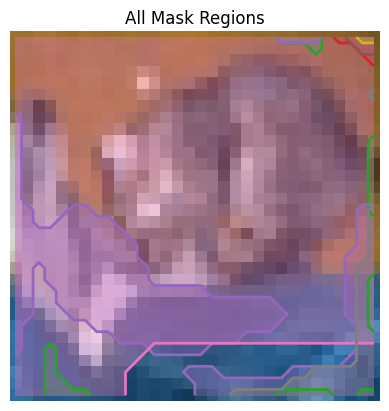

In [56]:
import matplotlib.pyplot as plt
import numpy as np


def plot_masks_together(mask, image, dset, threshold=0.5):
    mask = mask.detach().cpu().numpy()

    if hasattr(image, "detach"):
        image = image.detach().cpu().numpy()

    # CHW -> HWC
    if image.ndim == 3 and image.shape[0] in [1,3]:
        image = np.transpose(image, (1,2,0))

    # undo normalization
    mean = np.array(dset.mean)
    std = np.array(dset.std)
    image = image * std + mean
    image = np.clip(image, 0, 1)

    colors = plt.cm.tab10(np.linspace(0, 1, mask.shape[0]))

    plt.figure()
    plt.imshow(image)

    for i in range(mask.shape[0]):
        m = mask[i]
        m = gaussian_filter(m, sigma=1.0)
        binary = m > threshold

        if np.any(binary):  # avoid empty contours
            plt.contourf(
                binary,
                levels=[0.5, 1],
                colors=[colors[i]],
                alpha=0.35
            )

            plt.contour(
                binary,
                levels=[0.5],
                colors=[colors[i]],
                linewidths=2
            )

    plt.title("All Mask Regions")
    plt.axis("off")
    plt.show()



plot_masks_together(mask, image.squeeze(0), dset, threshold=(1-1e-6))